In [1]:
import torch
import pickle
from sbi.analysis import pairplot
from sbi.utils import BoxUniform
from sbi.utils.user_input_checks import (
    check_sbi_inputs,
    process_prior,
    process_simulator,
)

In [3]:
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

from sbi import analysis, utils
from sbi.inference import NPE, simulate_for_sbi
from sbi.utils.user_input_checks import (
    check_sbi_inputs,
    process_prior,
    process_simulator,
)

from JAX_Deprojection import utils as jax_utils
import jax.numpy as jnp
import numpy as np
import os
from sbi.neural_nets import posterior_nn
import pandas as pd
import pickle


In [6]:
pd.set_option('display.max_colwidth', None)

In [7]:
with open(r'Z:\Uni\Master_Astronomy\GitHub\JAX_deprojection\SBI_notebooks\dataframes\model_test_results.pkl', 'rb') as f:
    df = pickle.load(f)

# Group by `model_name` and calculate max, min, and average `img_score`
stats = df.groupby('model_name')['img_score'].agg(['max', 'min', 'mean']).reset_index()

# Print the statistics
stats

,model_name,max,min,mean
0,model_z_score_None_hidden_150_transforms_10.pkl,3.830127e+05,495.334167,15600.653320
1,model_z_score_None_hidden_150_transforms_100.pkl,5.762516e+05,519.478882,20222.636719
2,model_z_score_None_hidden_150_transforms_50.pkl,1.213559e+06,674.582336,26210.880859
3,model_z_score_None_hidden_300_transforms_10.pkl,1.025372e+06,639.172913,27638.210938
4,model_z_score_None_hidden_300_transforms_100.pkl,8.905218e+06,1509.232300,217056.796875
5,model_z_score_None_hidden_300_transforms_50.pkl,9.301889e+05,449.864319,27981.351562
6,model_z_score_None_hidden_50_transforms_10.pkl,9.298358e+05,947.997314,41010.253906
7,model_z_score_None_hidden_50_transforms_100.pkl,3.259956e+06,762.609192,90034.468750
8,model_z_score_None_hidden_50_transforms_50.pkl,6.341480e+05,804.239502,23046.839844
9,model_z_score_structured_hidden_150_transforms_10.pkl,5.024793e+05,840.329590,32389.734375


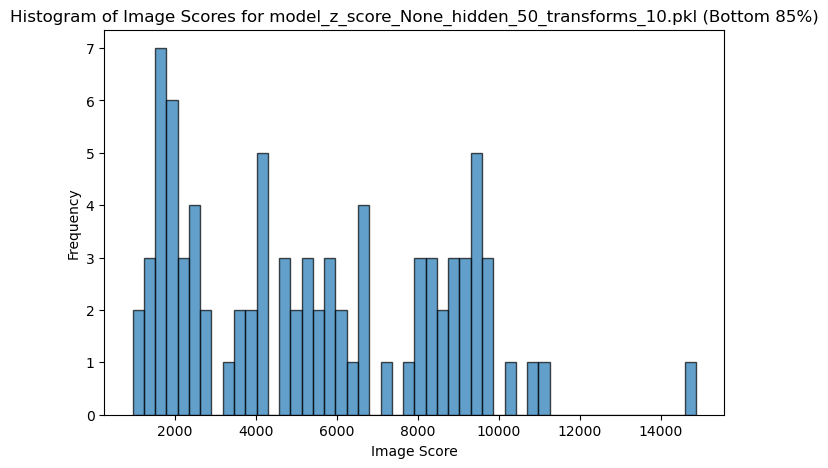

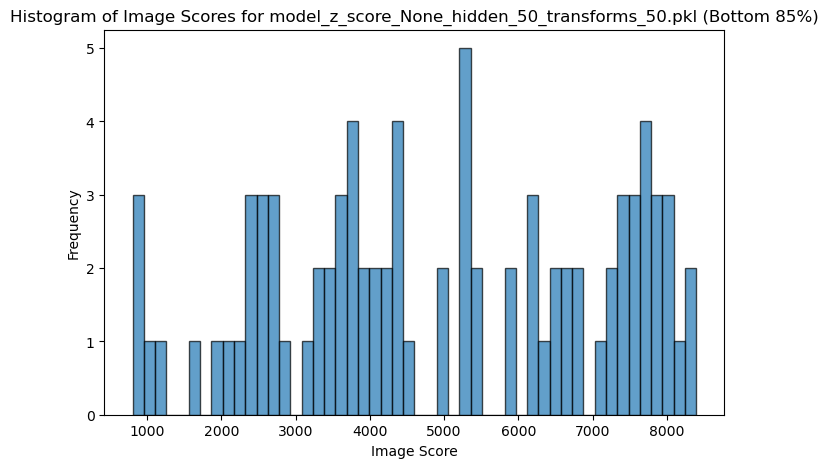

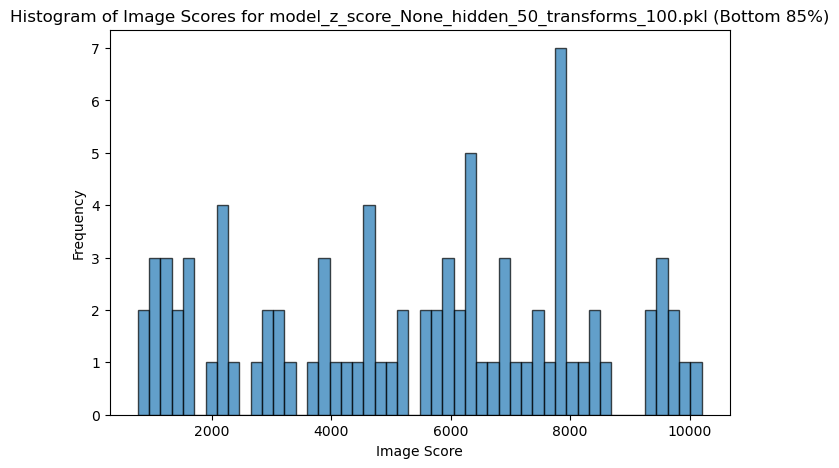

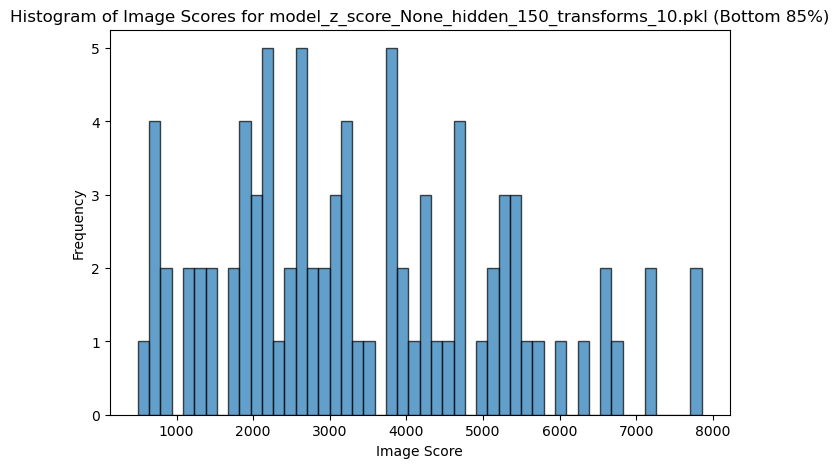

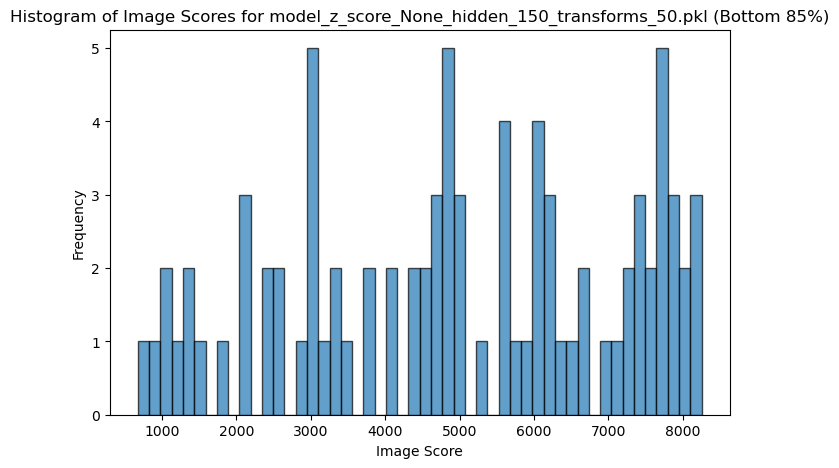

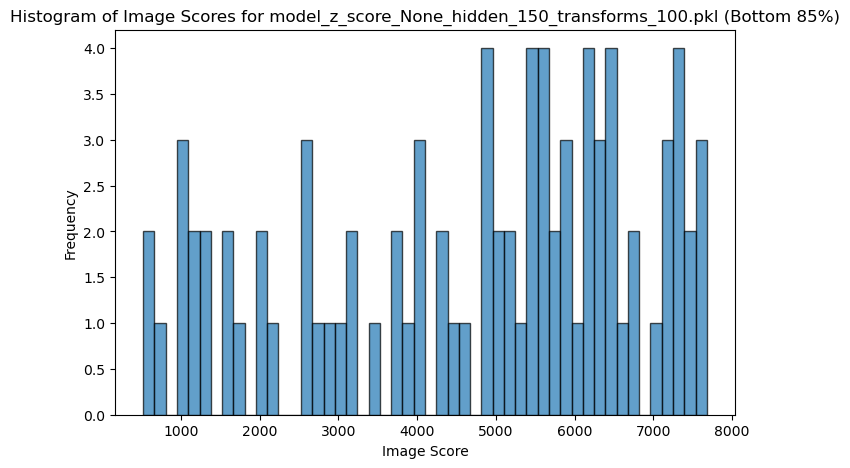

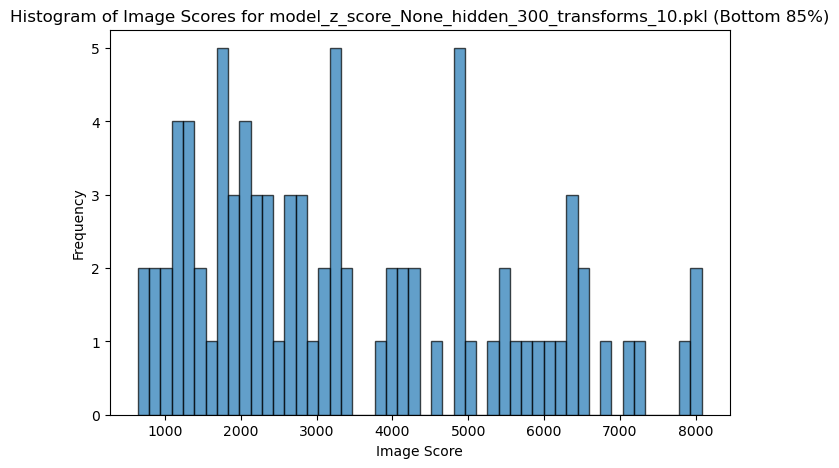

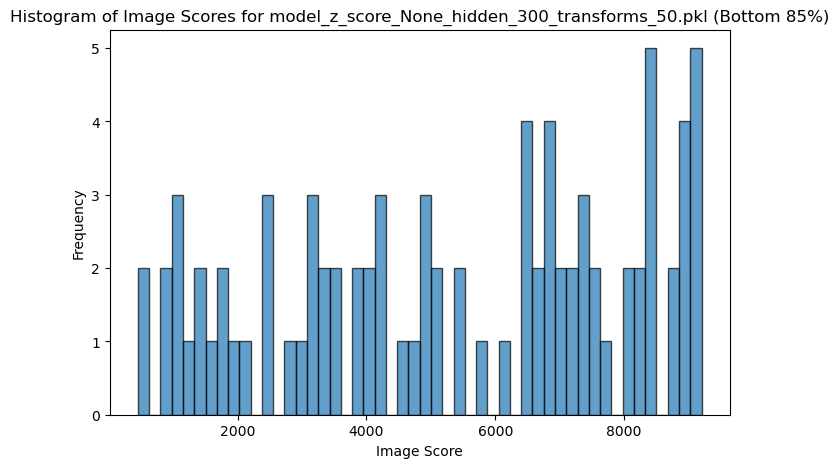

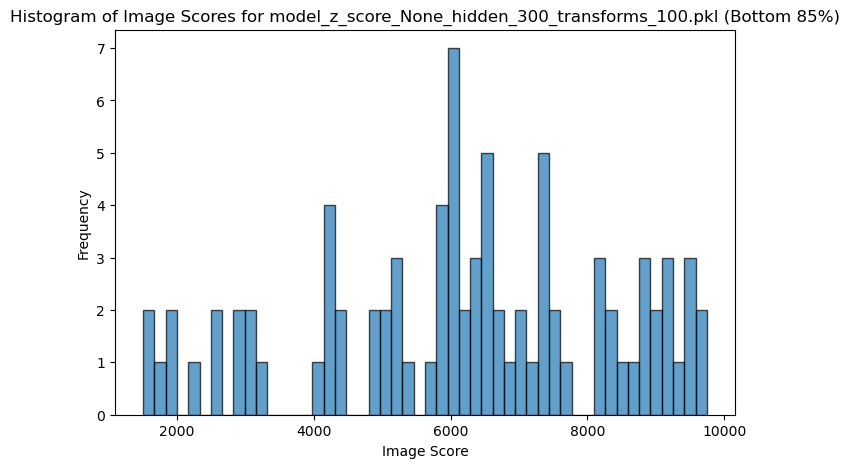

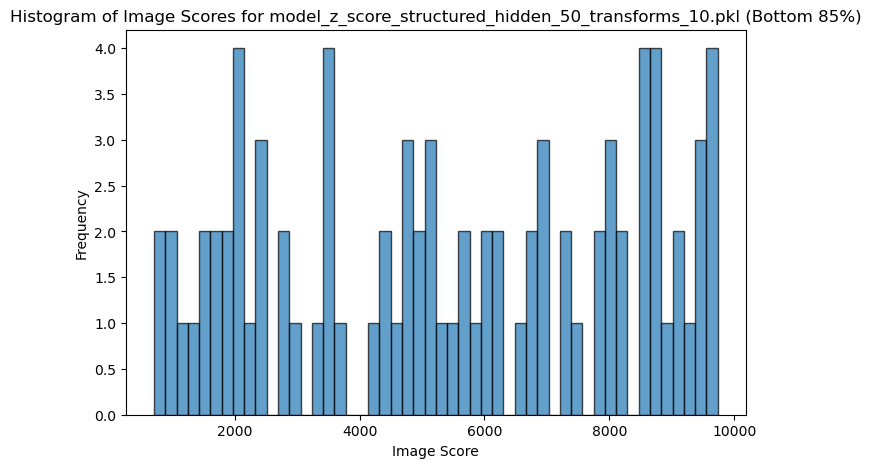

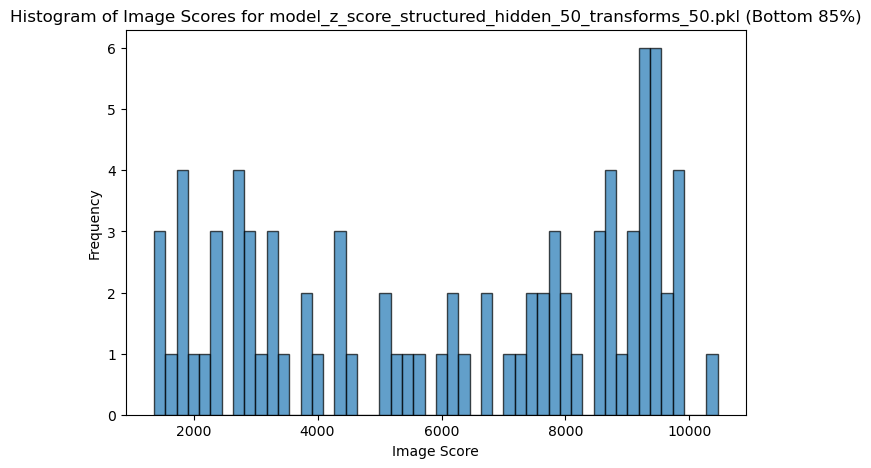

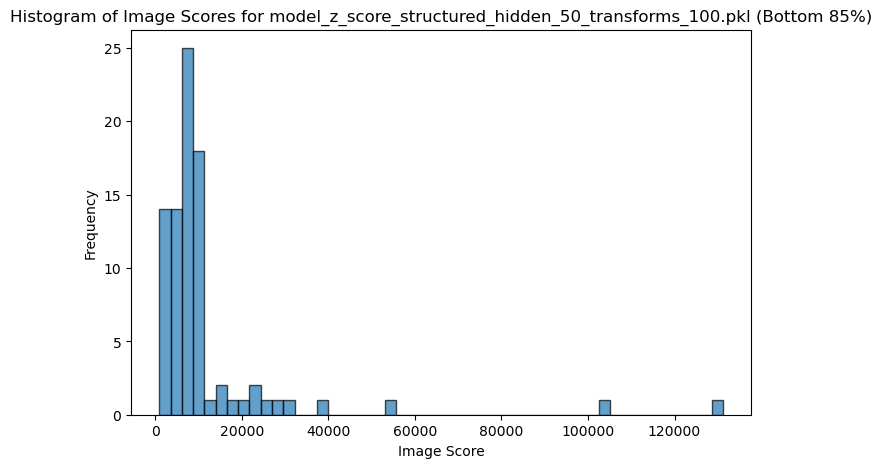

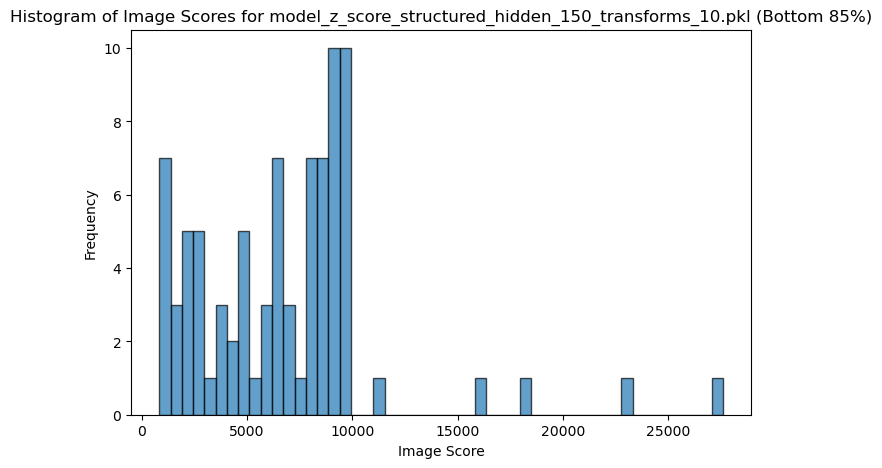

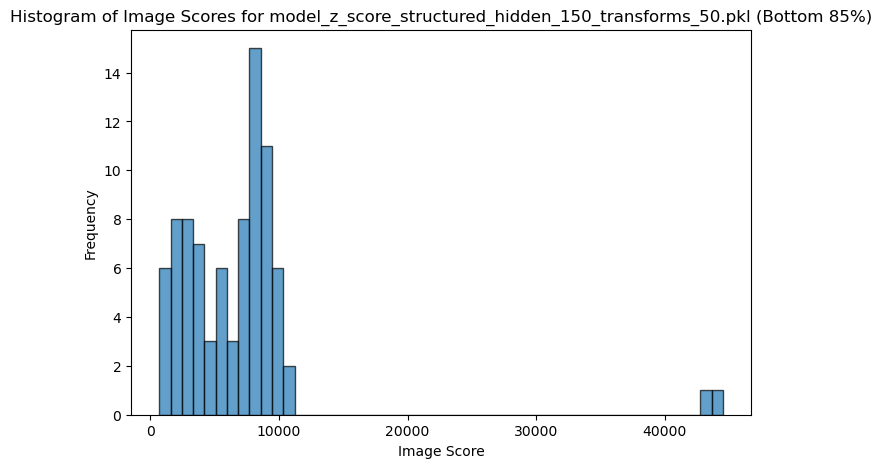

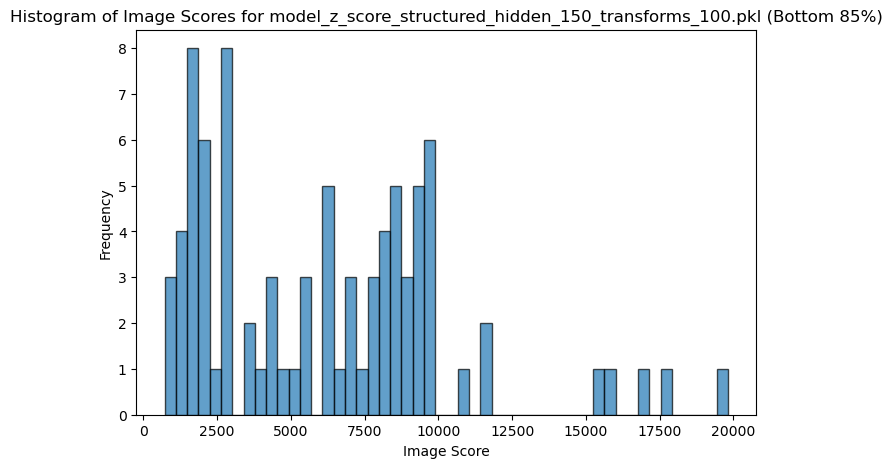

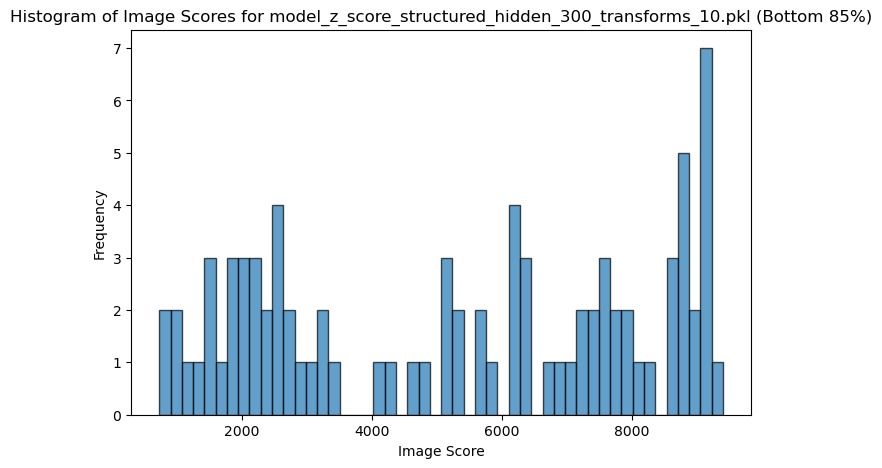

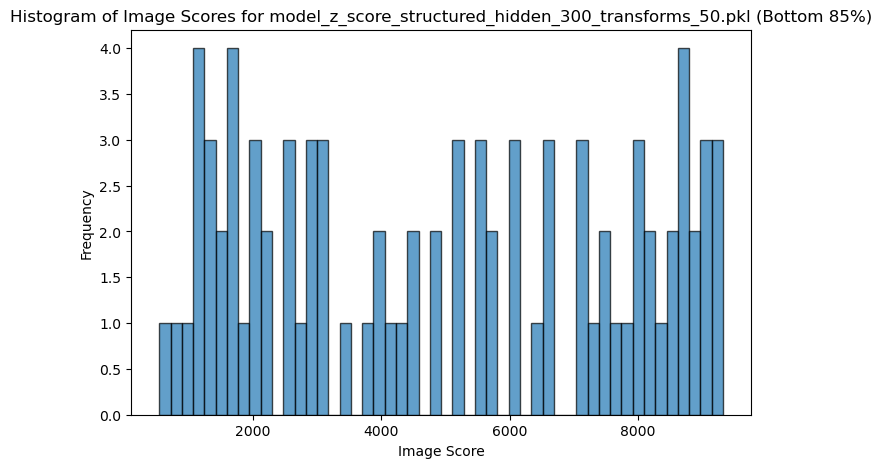

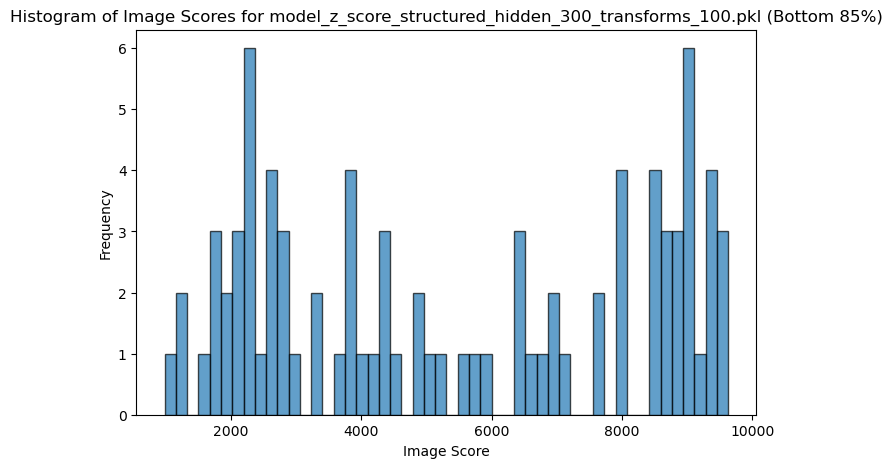

In [8]:
# Plot separate histograms for each `model_name` using the bottom 85% of data
for model_name in df['model_name'].unique():
    model_data = df[df['model_name'] == model_name]['img_score']
    
    # Calculate the 85th percentile for the current model
    threshold = model_data.quantile(0.85)
    
    # Filter the data to include only the bottom 85%
    filtered_data = model_data[model_data <= threshold]
    
    # Create a new figure for each model
    plt.figure(figsize=(8, 5))
    plt.hist(filtered_data, bins=50, alpha=0.7, edgecolor='black')
    
    # Add labels and title
    plt.title(f'Histogram of Image Scores for {model_name} (Bottom 85%)')
    plt.xlabel('Image Score')
    plt.ylabel('Frequency')
    
    # Show the plot
    plt.show()

In [9]:
with open(r'Z:\Uni\Master_Astronomy\GitHub\JAX_deprojection\SBI_notebooks\dataframes\model_test_results_40k.pkl', 'rb') as f:
    df = pickle.load(f)

# Group by `model_name` and calculate max, min, and average `img_score`
stats = df.groupby('model_name')['img_score'].agg(['max', 'min', 'mean']).reset_index()

# Print the statistics
stats

,model_name,max,min,mean
0,model_z_score_None_hidden_150_transforms_10_100.pkl,1531371.375,1070.581665,37864.468750
1,model_z_score_None_hidden_150_transforms_10_1000.pkl,2606077.000,431.654297,31205.644531


                                          model_name          max  \
0  model_z_score_None_hidden_150_transforms_10_10...  1531371.375   
1  model_z_score_None_hidden_150_transforms_10_10...  2606077.000   

           min          mean  
0  1070.581665  37864.468750  
1   431.654297  31205.644531  


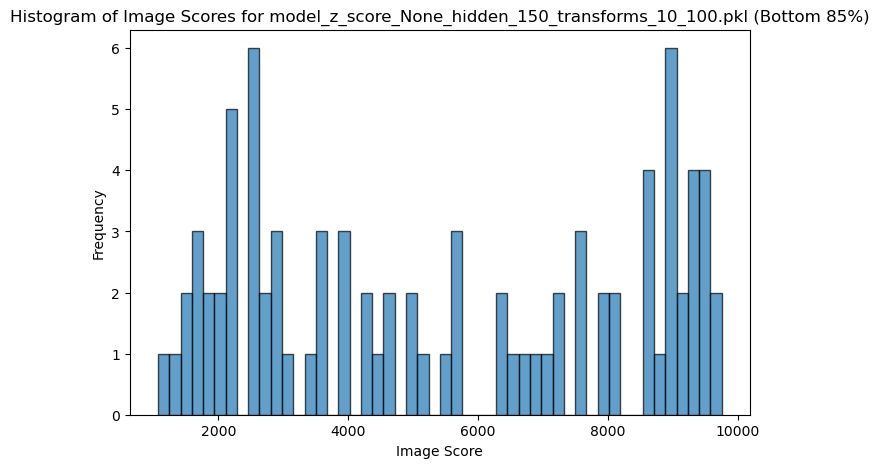

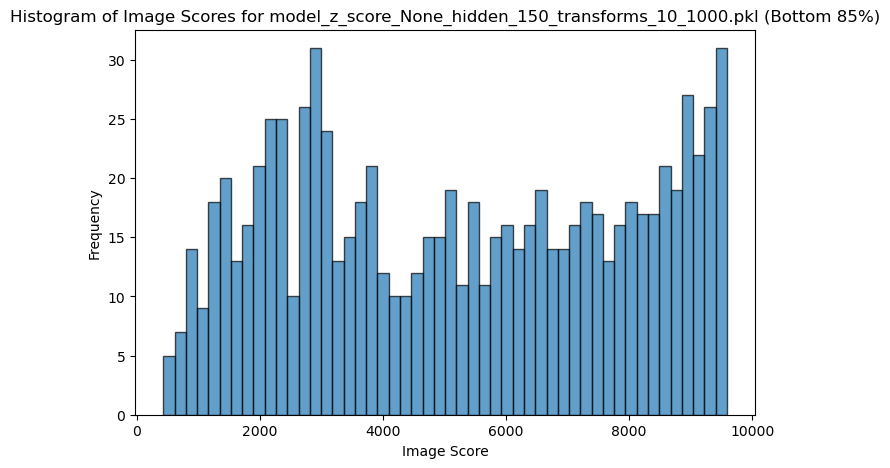

In [ ]:
# Plot separate histograms for each `model_name` using the bottom 85% of data
for model_name in df['model_name'].unique():
    model_data = df[df['model_name'] == model_name]['img_score']
    
    # Calculate the 85th percentile for the current model
    threshold = model_data.quantile(0.85)
    
    # Filter the data to include only the bottom 85%
    filtered_data = model_data[model_data <= threshold]
    
    # Create a new figure for each model
    plt.figure(figsize=(8, 5))
    plt.hist(filtered_data, bins=50, alpha=0.7, edgecolor='black')
    
    # Add labels and title
    plt.title(f'Histogram of Image Scores for {model_name} (Bottom 85%)')
    plt.xlabel('Image Score')
    plt.ylabel('Frequency')
    
    # Show the plot
    plt.show()

Comparison for 100 training points:

best parameter combination 5k training data: min : 495   avg: 15600

best parameter combination 40k training data: min : 1070 avg: 37864


For 1000 training points:

best parameter combination 40k training data: min : 431 avg: 31205

So the model with 40k training points performed worse than the model with 5k training points on the same dataset.

Training the bigger model took ~5,5h
Testing the 1100 test images took ~2h